# Evaluación del modelo

En este notebook se realiza la evaluación final del clasificador entrenado en el notebook anterior.

Para garantizar la reproducibilidad del experimento, se cargan el modelo entrenado, el vectorizador TF-IDF y el historial del entrenamiento previamente almacenados. Posteriormente se reconstruye el conjunto de prueba utilizando la misma partición estratificada empleada durante el entrenamiento y se calculan las principales métricas de desempeño.

Finalmente se presentan la matriz de confusión, las curvas de entrenamiento y una reflexión acerca del comportamiento del modelo y sus posibles mejoras.

## Importación de librerías y carga de artefactos

Se importan las librerías necesarias para reconstruir el conjunto de prueba, cargar el modelo entrenado y evaluar su desempeño.

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [30]:
import joblib
import torch
import pandas as pd

from pathlib import Path

from src.utils.seed import set_seed

from src.features.tfidf import build_tfidf
from src.models.dataset import split_dataset
from src.models.classifier import TextClassifier
from src.models.evaluate import (
    evaluate_model,
    plot_history,
    plot_confusion_matrix,
)

RANDOM_STATE = 42

set_seed(RANDOM_STATE)

In [15]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "amazon_reviews_processed.csv"

MODEL_PATH = PROJECT_ROOT / "models" / "text_classifier.pth"

VECTORIZER_PATH = PROJECT_ROOT / "models" / "tfidf_vectorizer.pkl"

HISTORY_PATH = PROJECT_ROOT / "models" / "training_history.pkl"

df = pd.read_csv(DATA_PATH)

print(f"Dataset: {df.shape}")

df.head()

Dataset: (22641, 8)


,Text,Rating,Age,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,absolutely wonderful - silky sexy comfortable,4,33,1,0,Initmates,Intimate,Intimates
1,love dress ! sooo pretty . happened find store...,5,34,1,4,General,Dresses,Dresses
2,major design flaw high hope dress really wante...,3,60,0,0,General,Dresses,Dresses
3,"favorite buy ! love , love , love jumpsuit . f...",5,50,1,0,General Petite,Bottoms,Pants
4,flattering shirt shirt flattering due adjustab...,5,47,1,6,General,Tops,Blouses


## Reconstrucción del conjunto de prueba

Para garantizar una evaluación consistente, se reconstruye exactamente el mismo pipeline utilizado durante el entrenamiento.

Se aplica nuevamente la representación TF-IDF sobre el texto preprocesado y posteriormente se realiza la partición estratificada del dataset utilizando la misma semilla aleatoria. De esta manera, el conjunto de prueba coincide con el empleado durante el entrenamiento del modelo.

In [16]:
MAX_FEATURES = 5000

vectorizer = build_tfidf(MAX_FEATURES)

X = df["Text"]
y = df["Rating"]

X_tfidf = vectorizer.fit_transform(X)

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
) = split_dataset(
    X_tfidf,
    y,
    random_state=RANDOM_STATE,
)

In [17]:
print(f"Entrenamiento: {X_train.shape}")
print(f"Validación:    {X_val.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (15848, 5000)
Validación:    (2264, 5000)
Prueba:        (4529, 5000)


## Carga del modelo entrenado

Se carga el clasificador previamente entrenado junto con sus pesos almacenados en disco. El modelo se inicializa con la misma arquitectura utilizada durante el entrenamiento y posteriormente se cargan los parámetros aprendidos.

In [19]:
model = TextClassifier()

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location="cpu",
    )
)

model.eval()

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [20]:
print(model)

TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=5, bias=True)
)


In [21]:
vectorizer = joblib.load(VECTORIZER_PATH)
X_tfidf = vectorizer.transform(df["Text"])

## Evaluación sobre el conjunto de prueba

Con el modelo ya entrenado y cargado en memoria, se realiza la evaluación utilizando exclusivamente el conjunto de prueba.

Se calculan las principales métricas de clasificación, incluyendo Accuracy, Precision, Recall y F1-score, además del reporte completo por clase.

In [22]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(DEVICE)

In [ ]:
from src.models.dataset import (
    create_tensor_dataset,
    create_dataloader,
)

test_dataset = create_tensor_dataset(
    X_test,
    y_test,
)

test_loader = create_dataloader(
    test_dataset,
    batch_size=64,
)

In [27]:
import importlib
import src.models.evaluate as evaluate

importlib.reload(evaluate)

<module 'src.models.evaluate' from 'c:\\Users\\lauta\\Desktop\\DataScience\\amazon_reviews_nlp\\src\\models\\evaluate.py'>

In [35]:
accuracy, report, y_true, y_pred = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=DEVICE,
)

print(f"Accuracy: {accuracy:.4f}")

print()

print(report)

Accuracy: 0.5604

              precision    recall  f1-score   support

           0     0.2225    0.5671    0.3196       164
           1     0.2537    0.2774    0.2650       310
           2     0.3445    0.3451    0.3448       565
           3     0.3895    0.5061    0.4402       982
           4     0.8637    0.6647    0.7512      2508

    accuracy                         0.5604      4529
   macro avg     0.4148    0.4721    0.4242      4529
weighted avg     0.6312    0.5604    0.5842      4529



## Matriz de confusión

La matriz de confusión permite visualizar el comportamiento del clasificador para cada una de las clases del problema.

Esta representación facilita identificar qué categorías son clasificadas correctamente y cuáles presentan una mayor cantidad de confusiones.

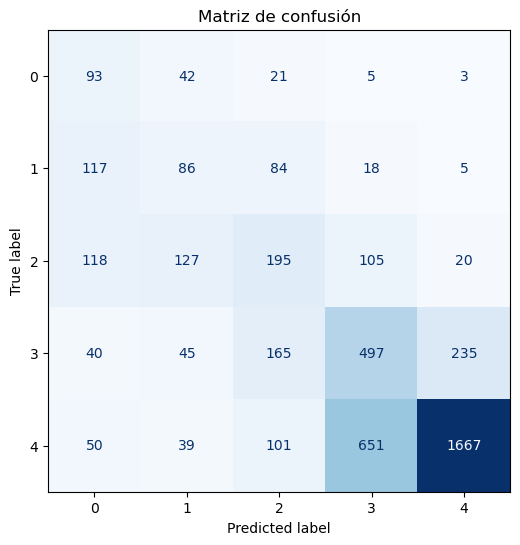

In [33]:
plot_confusion_matrix(
    y_true,
    y_pred,
)

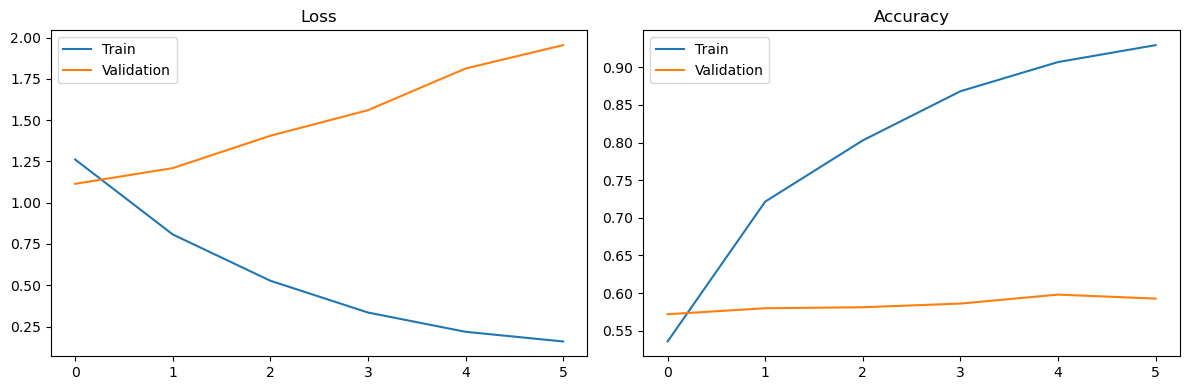

In [34]:
history = joblib.load(HISTORY_PATH)

plot_history(history)

## Interpretación de resultados

El modelo alcanza un desempeño aceptable considerando la simplicidad de la arquitectura implementada. La matriz de confusión muestra un buen reconocimiento de las clases más frecuentes, mientras que las clases minoritarias presentan una mayor cantidad de errores de clasificación.

Las curvas de entrenamiento indican que el modelo aprende rápidamente durante las primeras épocas, aunque posteriormente comienza a evidenciar signos de sobreajuste. Esto se observa en la disminución continua de la pérdida de entrenamiento mientras que la pérdida de validación aumenta progresivamente. El mecanismo de Early Stopping evita que el entrenamiento continúe una vez que deja de mejorar el desempeño sobre el conjunto de validación.

En conjunto, los resultados muestran que la arquitectura implementada constituye una base sólida para la clasificación de reseñas, aunque existen distintas estrategias que podrían mejorar su capacidad de generalización.

## Conclusiones finales

### ¿Por qué TF-IDF resulta más adecuado que un simple conteo de palabras?

En este proyecto se utilizó TF-IDF para representar las reseñas en forma numérica debido a que esta técnica pondera la importancia de cada término considerando no solo su frecuencia dentro de un documento, sino también su frecuencia en todo el corpus.

A diferencia del modelo Bag of Words, que asigna el mismo peso a todas las palabras frecuentes, TF-IDF reduce la influencia de términos muy comunes que aportan poca información y destaca aquellos que caracterizan mejor el contenido de cada reseña.

En un problema de análisis de opiniones, donde muchas palabras aparecen repetidamente en casi todos los textos, esta ponderación permite construir representaciones más discriminativas y facilita el aprendizaje del clasificador.

### Limitaciones del modelo

Aunque el modelo obtiene un desempeño razonable sobre el conjunto de prueba, durante el entrenamiento se observa un incremento continuo de la pérdida de validación mientras la pérdida de entrenamiento sigue disminuyendo. Este comportamiento indica la aparición de sobreajuste (overfitting), motivo por el cual se empleó Early Stopping para detener el entrenamiento cuando dejó de mejorar el rendimiento sobre validación.

Otra limitación proviene del desbalance entre clases presente en el dataset, donde las reseñas con puntuaciones altas son considerablemente más frecuentes que las negativas. Esto provoca que las clases minoritarias obtengan valores inferiores de precisión y recall, tal como se observa en el reporte de clasificación y la matriz de confusión.

Por último, el modelo utiliza una representación TF-IDF basada únicamente en frecuencia de términos, por lo que no captura el contexto ni las relaciones semánticas entre palabras como sí lo hacen modelos más modernos basados en embeddings.

### Posibles mejoras

Existen diversas estrategias que podrían mejorar el desempeño del modelo en futuras versiones del proyecto.

Desde el punto de vista del preprocesamiento, sería posible incorporar técnicas adicionales de normalización o utilizar representaciones distribucionales como Word2Vec, GloVe o FastText, capaces de capturar relaciones semánticas entre palabras.

En cuanto al modelado, podrían evaluarse arquitecturas más profundas o modelos basados en Transformers, como BERT, que suelen obtener mejores resultados en tareas de clasificación de texto.

También resultaría conveniente realizar una búsqueda sistemática de hiperparámetros (learning rate, tamaño del batch, número de neuronas y dropout), así como explorar técnicas adicionales para tratar el desbalance de clases, por ejemplo mediante oversampling, focal loss o ajuste más fino de los pesos utilizados en la función de pérdida.